In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

# 1 Load data

## 1.1 Load population

In [2]:
pop_df = pd.read_csv('Pop ML V PIPE.csv', encoding='latin-1', sep='|')
pop_df.head(10)

,MSISDN,STATE_IN,SUBSCRIBER_TYPE_IN,RATE_PLAN,ACCOUNT_ACTIVATED_DATE
0,21697077044,ACTIVE,PREPAID,PRE - Classic,2003-12-19
1,21697076876,ACTIVE,PREPAID,PRE - Classic,2021-11-23
2,21697072547,ACTIVE,PREPAID,PRE - Classic,2020-09-14
3,21697068526,ACTIVE,PREPAID,PRE - Classic,2018-04-11
4,21697061045,ACTIVE,PREPAID,PRE - Classic,2003-11-15
5,21697060361,ACTIVE,PREPAID,PRE - Classic,2003-11-06
6,21697057138,ACTIVE,PREPAID,PRE - Classic,2004-02-01
7,21697046515,ACTIVE,PREPAID,PRE - Classic,2023-04-22
8,21697038087,SUSPENDED,PREPAID,PRE - Classic,2024-03-10
9,21697026893,SUSPENDED,PREPAID,PRE - Classic,2025-01-25


## 1.2 Load SOS

In [3]:
sos_df = pd.read_csv('DS_SOS_ML.csv', encoding='latin-1', sep='|')
sos_df.head(10)

,MSISDN,LOAN_ID,SOS_TYPE,CREDIT_DATE,CREDIT_AMOUNT,TOTAL_REIMBURSED,OUTSTANDING_AMOUNT,LAST_REIMBURSE_DATE,REIMBURSE_RATIO,REIMBURSE_STATUS,DAYS_SINCE_CREDIT
0,21650142555,528139435,CVAS_SOS_CR_DATA,09/01/2026,"4,5","4,5",0,23/01/2026,1,FULL,90
1,21693464197,528150918,CVAS_SOS_CR_SOLDE,09/01/2026,"0,5","0,5",0,09/01/2026,1,FULL,90
2,21697349073,528136747,CVAS_SOS_CR_SOLDE,09/01/2026,5,5,0,10/01/2026,1,FULL,90
3,21698641675,528163694,CVAS_SOS_CR_SOLDE,09/01/2026,3,3,0,15/01/2026,1,FULL,90
4,21694195742,528176161,CVAS_SOS_CR_DATA,09/01/2026,"0,9","0,9",0,09/01/2026,1,FULL,90
5,21693574965,528132046,CVAS_SOS_CR_SOLDE,09/01/2026,"2,5","2,5",0,19/01/2026,1,FULL,90
6,21696646805,528207682,CVAS_SOS_CR_SOLDE,09/01/2026,5,5,0,19/01/2026,1,FULL,90
7,21693370117,528155180,CVAS_SOS_CR_SOLDE,09/01/2026,"0,5","0,5",0,09/01/2026,1,FULL,90
8,21697385533,528223219,CVAS_SOS_CR_DATA,09/01/2026,"0,25","0,25",0,09/01/2026,1,FULL,90
9,21695867328,528161149,CVAS_SOS_CR_DATA,09/01/2026,"0,9","0,9",0,10/01/2026,1,FULL,90


# 2 Data Preparation for Model

## 2.1 Merge datasets on MSISDN

In [4]:
# Merge datasets on MSISDN
df = sos_df.merge(pop_df[['MSISDN', 'SUBSCRIBER_TYPE_IN', 'RATE_PLAN', 'ACCOUNT_ACTIVATED_DATE']], 
                   on='MSISDN', how='inner')

print(f"Merged dataset shape: {df.shape}")
print(f"\nColumns in merged dataset: {df.columns.tolist()}")
print(f"\nNull values after merge:")
print(df[['SOS_TYPE', 'SUBSCRIBER_TYPE_IN', 'RATE_PLAN', 'ACCOUNT_ACTIVATED_DATE', 'CREDIT_DATE', 'CREDIT_AMOUNT']].isnull().sum())

Merged dataset shape: (18562478, 14)

Columns in merged dataset: ['MSISDN', 'LOAN_ID', 'SOS_TYPE', 'CREDIT_DATE', 'CREDIT_AMOUNT', 'TOTAL_REIMBURSED', 'OUTSTANDING_AMOUNT', 'LAST_REIMBURSE_DATE', 'REIMBURSE_RATIO', 'REIMBURSE_STATUS', 'DAYS_SINCE_CREDIT', 'SUBSCRIBER_TYPE_IN', 'RATE_PLAN', 'ACCOUNT_ACTIVATED_DATE']

Null values after merge:
SOS_TYPE                      0
SUBSCRIBER_TYPE_IN        35004
RATE_PLAN                 35004
ACCOUNT_ACTIVATED_DATE    35004
CREDIT_DATE                   0
CREDIT_AMOUNT                 0
dtype: int64


## 2.2 Data Cleaning - Remove rows with null values in required features

In [5]:
# Data Cleaning - Remove rows with null values in required features
required_cols = ["MSISDN",'SOS_TYPE', 'SUBSCRIBER_TYPE_IN', 'ACCOUNT_ACTIVATED_DATE', 'CREDIT_DATE', 'CREDIT_AMOUNT']
df_clean = df.dropna(subset=required_cols).copy()

print(f"Dataset shape after removing nulls: {df_clean.shape}")
print(f"Rows removed: {df.shape[0] - df_clean.shape[0]}")
print(f"\nRemaining null values:")
print(df_clean[required_cols].isnull().sum())

Dataset shape after removing nulls: (18527474, 14)
Rows removed: 35004

Remaining null values:
MSISDN                    0
SOS_TYPE                  0
SUBSCRIBER_TYPE_IN        0
ACCOUNT_ACTIVATED_DATE    0
CREDIT_DATE               0
CREDIT_AMOUNT             0
dtype: int64


## 2.3 Convert date columns to datetime

In [6]:
# Convert date columns to datetime
df_clean['ACCOUNT_ACTIVATED_DATE'] = pd.to_datetime(df_clean['ACCOUNT_ACTIVATED_DATE'], errors='coerce')
df_clean['CREDIT_DATE'] = pd.to_datetime(df_clean['CREDIT_DATE'], errors='coerce')
# Convert amount from text like "4,5" to numeric 4.5
df_clean["CREDIT_AMOUNT"] = (
    df_clean["CREDIT_AMOUNT"]
    .astype(str)
    .str.replace(",", ".", regex=False)
)

df_clean["CREDIT_AMOUNT"] = pd.to_numeric(df_clean["CREDIT_AMOUNT"], errors="coerce")
# Remove rows where date conversion failed
df_clean = df_clean.dropna(subset=['ACCOUNT_ACTIVATED_DATE', 'CREDIT_DATE'])

print(f"Dataset shape after date conversion: {df_clean.shape}")
print(f"\nDate columns info:")
print(f"ACCOUNT_ACTIVATED_DATE - min: {df_clean['ACCOUNT_ACTIVATED_DATE'].min()}, max: {df_clean['ACCOUNT_ACTIVATED_DATE'].max()}")
print(f"CREDIT_DATE - min: {df_clean['CREDIT_DATE'].min()}, max: {df_clean['CREDIT_DATE'].max()}")

Dataset shape after date conversion: (7195753, 14)

Date columns info:
ACCOUNT_ACTIVATED_DATE - min: 2000-12-15 00:00:00, max: 2026-04-07 00:00:00
CREDIT_DATE - min: 2026-01-02 00:00:00, max: 2026-12-03 00:00:00


## 2.4 Feature Engineering - Derive new columns

In [7]:
# Engineer additional required features
from datetime import datetime

# Calculate CUSTOMER_AGE (days since account activation as of credit date or today)
df_clean['CUSTOMER_AGE'] = (df_clean['CREDIT_DATE'] - df_clean['ACCOUNT_ACTIVATED_DATE']).dt.days

# Calculate NUMBER_OF_PREVIOUS_LOANS (number of loans per MSISDN before the current one)
# This requires grouping by MSISDN and counting
loan_counts = df_clean.groupby('MSISDN').cumcount()
df_clean['NUMBER_OF_PREVIOUS_LOANS'] = loan_counts

# PREVIOUS_DEFAULT_FLAG - check if REIMBURSE_STATUS indicates any default payment patterns
# We'll create this as 0 initially and update based on outstanding amount ratio
df_clean['PREVIOUS_DEFAULT_FLAG'] = (
    pd.to_numeric(
        df_clean['OUTSTANDING_AMOUNT'].astype(str).str.replace(",", ".", regex=False),
        errors="coerce"
    )
    .gt(0)
    .fillna(False)
    .astype(int)
)

# AVG_REPAYMENT_DELAY - calculate from REIMBURSE_RATIO and LAST_REIMBURSE_DATE
# If REIMBURSE_RATIO < 1, it indicates delayed or partial payment
# Calculate days between credit date and last reimbursement date
df_clean['LAST_REIMBURSE_DATE'] = pd.to_datetime(df_clean['LAST_REIMBURSE_DATE'], errors='coerce')
df_clean['AVG_REPAYMENT_DELAY'] = (
    df_clean['LAST_REIMBURSE_DATE'] - df_clean['CREDIT_DATE']
).dt.days
df_clean['AVG_REPAYMENT_DELAY'] = df_clean['AVG_REPAYMENT_DELAY'].fillna(0)

# Handle negative values (reimbursement before credit) - set to 0
df_clean['AVG_REPAYMENT_DELAY'] = df_clean['AVG_REPAYMENT_DELAY'].clip(lower=0)

print("✓ Feature Engineering completed!")
print(f"\nNew features created:")
print(f"  - CUSTOMER_AGE: {df_clean['CUSTOMER_AGE'].min()} to {df_clean['CUSTOMER_AGE'].max()} days")
print(f"  - NUMBER_OF_PREVIOUS_LOANS: {df_clean['NUMBER_OF_PREVIOUS_LOANS'].min()} to {df_clean['NUMBER_OF_PREVIOUS_LOANS'].max()}")
print(f"  - PREVIOUS_DEFAULT_FLAG: {df_clean['PREVIOUS_DEFAULT_FLAG'].value_counts().to_dict()}")
print(f"  - AVG_REPAYMENT_DELAY: {df_clean['AVG_REPAYMENT_DELAY'].min():.0f} to {df_clean['AVG_REPAYMENT_DELAY'].max():.0f} days")
print(f"\nNull values in new features:")
print(df_clean[['CUSTOMER_AGE', 'NUMBER_OF_PREVIOUS_LOANS', 'PREVIOUS_DEFAULT_FLAG', 'AVG_REPAYMENT_DELAY']].isnull().sum())

C:\Users\micro\AppData\Local\Temp\ipykernel_11064\2505660275.py:27: UserWarning: Parsing dates in %d/%m/%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df_clean['LAST_REIMBURSE_DATE'] = pd.to_datetime(df_clean['LAST_REIMBURSE_DATE'], errors='coerce')


✓ Feature Engineering completed!

New features created:
  - CUSTOMER_AGE: -95 to 9484 days
  - NUMBER_OF_PREVIOUS_LOANS: 0 to 513
  - PREVIOUS_DEFAULT_FLAG: {0: 5571640, 1: 1624113}
  - AVG_REPAYMENT_DELAY: 0 to 96 days

Null values in new features:
CUSTOMER_AGE                0
NUMBER_OF_PREVIOUS_LOANS    0
PREVIOUS_DEFAULT_FLAG       0
AVG_REPAYMENT_DELAY         0
dtype: int64


In [8]:
# Note: DAYS_SINCE_CREDIT is already in the dataset
# Verify it exists and has valid values
print("✓ Verifying DAYS_SINCE_CREDIT from source data:")
print(f"  - Min: {df_clean['DAYS_SINCE_CREDIT'].min()}")
print(f"  - Max: {df_clean['DAYS_SINCE_CREDIT'].max()}")
print(f"  - Mean: {df_clean['DAYS_SINCE_CREDIT'].mean():.2f}")
print(f"  - Null count: {df_clean['DAYS_SINCE_CREDIT'].isnull().sum()}")

✓ Verifying DAYS_SINCE_CREDIT from source data:
  - Min: 1
  - Max: 90
  - Mean: 42.80
  - Null count: 0


In [9]:
# Check available columns and required features
required_features = ['CREDIT_AMOUNT', 'DAYS_SINCE_CREDIT', 'SUBSCRIBER_TYPE_IN', 'RATE_PLAN', 
                     'CUSTOMER_AGE', 'NUMBER_OF_PREVIOUS_LOANS', 'PREVIOUS_DEFAULT_FLAG', 
                     'AVG_REPAYMENT_DELAY', 'REIMBURSE_STATUS']

print("✓ Required features for XGBClassifier:")
for feat in required_features:
    print(f"  - {feat}")

print("\n✓ Available columns in dataset:")
print(df_clean.columns.tolist())

print("\n✓ Checking feature availability:")
missing_features = []
for col in required_features:
    if col in df_clean.columns:
        print(f"  ✓ {col} - FOUND")
    else:
        print(f"  ✗ {col} - NOT FOUND")
        missing_features.append(col)

if missing_features:
    print(f"\n⚠ Missing features: {missing_features}")
else:
    print(f"\n✓ All required features are available!")

✓ Required features for XGBClassifier:
  - CREDIT_AMOUNT
  - DAYS_SINCE_CREDIT
  - SUBSCRIBER_TYPE_IN
  - RATE_PLAN
  - CUSTOMER_AGE
  - NUMBER_OF_PREVIOUS_LOANS
  - PREVIOUS_DEFAULT_FLAG
  - AVG_REPAYMENT_DELAY
  - REIMBURSE_STATUS

✓ Available columns in dataset:
['MSISDN', 'LOAN_ID', 'SOS_TYPE', 'CREDIT_DATE', 'CREDIT_AMOUNT', 'TOTAL_REIMBURSED', 'OUTSTANDING_AMOUNT', 'LAST_REIMBURSE_DATE', 'REIMBURSE_RATIO', 'REIMBURSE_STATUS', 'DAYS_SINCE_CREDIT', 'SUBSCRIBER_TYPE_IN', 'RATE_PLAN', 'ACCOUNT_ACTIVATED_DATE', 'CUSTOMER_AGE', 'NUMBER_OF_PREVIOUS_LOANS', 'PREVIOUS_DEFAULT_FLAG', 'AVG_REPAYMENT_DELAY']

✓ Checking feature availability:
  ✓ CREDIT_AMOUNT - FOUND
  ✓ DAYS_SINCE_CREDIT - FOUND
  ✓ SUBSCRIBER_TYPE_IN - FOUND
  ✓ RATE_PLAN - FOUND
  ✓ CUSTOMER_AGE - FOUND
  ✓ NUMBER_OF_PREVIOUS_LOANS - FOUND
  ✓ PREVIOUS_DEFAULT_FLAG - FOUND
  ✓ AVG_REPAYMENT_DELAY - FOUND
  ✓ REIMBURSE_STATUS - FOUND

✓ All required features are available!


In [10]:
# Select required features and target variable
features = ['CREDIT_AMOUNT', 'DAYS_SINCE_CREDIT', 'SUBSCRIBER_TYPE_IN', 'RATE_PLAN', 
            'CUSTOMER_AGE', 'NUMBER_OF_PREVIOUS_LOANS', 'PREVIOUS_DEFAULT_FLAG', 'AVG_REPAYMENT_DELAY']
target = 'REIMBURSE_STATUS'

# Create a subset with only required features and target
df_model = df_clean[features + [target]].copy()

print(f"✓ Model dataset shape: {df_model.shape}")
print(f"\n✓ Features selected: {features}")
print(f"✓ Target: {target}")
print(f"\n✓ Null values in each feature:")
null_counts = df_model.isnull().sum()
print(null_counts[null_counts > 0] if null_counts.sum() > 0 else "No null values found!")
print(f"\n✓ Data types:")
print(df_model.dtypes)

✓ Model dataset shape: (7195753, 9)

✓ Features selected: ['CREDIT_AMOUNT', 'DAYS_SINCE_CREDIT', 'SUBSCRIBER_TYPE_IN', 'RATE_PLAN', 'CUSTOMER_AGE', 'NUMBER_OF_PREVIOUS_LOANS', 'PREVIOUS_DEFAULT_FLAG', 'AVG_REPAYMENT_DELAY']
✓ Target: REIMBURSE_STATUS

✓ Null values in each feature:
No null values found!

✓ Data types:
CREDIT_AMOUNT               float64
DAYS_SINCE_CREDIT             int64
SUBSCRIBER_TYPE_IN           object
RATE_PLAN                    object
CUSTOMER_AGE                  int64
NUMBER_OF_PREVIOUS_LOANS      int64
PREVIOUS_DEFAULT_FLAG         int32
AVG_REPAYMENT_DELAY         float64
REIMBURSE_STATUS             object
dtype: object


In [11]:
# Remove rows with any remaining null values
df_model_clean = df_model.dropna()

print(f"Dataset shape after removing nulls: {df_model_clean.shape}")
print(f"Rows removed: {df_model.shape[0] - df_model_clean.shape[0]}")
print(f"\nTarget variable (REIMBURSE_STATUS) value counts:")
print(df_model_clean[target].value_counts())
print(f"\nTarget variable distribution (%):")
print(df_model_clean[target].value_counts(normalize=True) * 100)

Dataset shape after removing nulls: (7195753, 9)
Rows removed: 0

Target variable (REIMBURSE_STATUS) value counts:
REIMBURSE_STATUS
FULL       5571640
UNPAID     1487672
PARTIAL     136441
Name: count, dtype: int64

Target variable distribution (%):
REIMBURSE_STATUS
FULL       77.429562
UNPAID     20.674306
PARTIAL     1.896132
Name: proportion, dtype: float64


In [12]:
# Identify categorical and numerical features
X = df_model_clean[features]
y = df_model_clean[target]

categorical_features = ['SUBSCRIBER_TYPE_IN', 'RATE_PLAN', 'PREVIOUS_DEFAULT_FLAG']
numerical_features = ['CREDIT_AMOUNT', 'DAYS_SINCE_CREDIT', 'CUSTOMER_AGE', 
                      'NUMBER_OF_PREVIOUS_LOANS', 'AVG_REPAYMENT_DELAY']

print(f"Categorical features: {categorical_features}")
print(f"Numerical features: {numerical_features}")
print(f"\nFeature matrix shape: {X.shape}")
print(f"Target shape: {y.shape}")

Categorical features: ['SUBSCRIBER_TYPE_IN', 'RATE_PLAN', 'PREVIOUS_DEFAULT_FLAG']
Numerical features: ['CREDIT_AMOUNT', 'DAYS_SINCE_CREDIT', 'CUSTOMER_AGE', 'NUMBER_OF_PREVIOUS_LOANS', 'AVG_REPAYMENT_DELAY']

Feature matrix shape: (7195753, 8)
Target shape: (7195753,)


In [14]:
# Create preprocessing pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder


# Fit and transform the data
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=True), categorical_features)
    ]
)

X_processed = preprocessor.fit_transform(X)

# Get feature names after transformation
feature_names_after_transform = (
    numerical_features +
    list(preprocessor.named_transformers_['cat'].get_feature_names_out(categorical_features))
)

print(f"Processed feature matrix shape: {X_processed.shape}")
print(f"Feature names after transformation: {len(feature_names_after_transform)}")
print(f"First 10 features: {feature_names_after_transform[:10]}")

Processed feature matrix shape: (7195753, 109)
Feature names after transformation: 109
First 10 features: ['CREDIT_AMOUNT', 'DAYS_SINCE_CREDIT', 'CUSTOMER_AGE', 'NUMBER_OF_PREVIOUS_LOANS', 'AVG_REPAYMENT_DELAY', 'SUBSCRIBER_TYPE_IN_HYB', 'SUBSCRIBER_TYPE_IN_POSTPAID', 'SUBSCRIBER_TYPE_IN_PREPAID', 'RATE_PLAN_Aziza Mobile 35Mil', 'RATE_PLAN_Cle 3G Prepaye']


In [15]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set size: {X_train.shape[0]}")
print(f"Test set size: {X_test.shape[0]}")
print(f"\nTraining set target distribution:")
print(pd.Series(y_train).value_counts())
print(f"\nTest set target distribution:")
print(pd.Series(y_test).value_counts())

Training set size: 5756602
Test set size: 1439151

Training set target distribution:
REIMBURSE_STATUS
FULL       4457312
UNPAID     1190137
PARTIAL     109153
Name: count, dtype: int64

Test set target distribution:
REIMBURSE_STATUS
FULL       1114328
UNPAID      297535
PARTIAL      27288
Name: count, dtype: int64


In [18]:
# Build XGBClassifier model
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    use_label_encoder=False,
    eval_metric='logloss'
)

# Train the model
print("Training XGBClassifier model...")
label_encoder = LabelEncoder()
y_train = label_encoder.fit_transform(y_train)
y_test = label_encoder.transform(y_test)

xgb_model.fit(X_train, y_train)
print("Model training completed!")

Training XGBClassifier model...


c:\Users\micro\anaconda3\Lib\site-packages\xgboost\core.py:158: UserWarning: [14:31:01] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-0c55ff5f71b100e98-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


Model training completed!


In [19]:
# Make predictions
y_train_pred = xgb_model.predict(X_train)
y_test_pred = xgb_model.predict(X_test)

# Get prediction probabilities
y_train_pred_proba = xgb_model.predict_proba(X_train)
y_test_pred_proba = xgb_model.predict_proba(X_test)

print("Predictions completed!")
print(f"Training set predictions shape: {y_train_pred.shape}")
print(f"Test set predictions shape: {y_test_pred.shape}")

Predictions completed!
Training set predictions shape: (5756602,)
Test set predictions shape: (1439151,)


In [20]:
# Evaluate model on training set
train_accuracy = accuracy_score(y_train, y_train_pred)
train_precision = precision_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_recall = recall_score(y_train, y_train_pred, average='weighted', zero_division=0)
train_f1 = f1_score(y_train, y_train_pred, average='weighted', zero_division=0)

print("=" * 50)
print("TRAINING SET PERFORMANCE")
print("=" * 50)
print(f"Accuracy:  {train_accuracy:.4f}")
print(f"Precision: {train_precision:.4f}")
print(f"Recall:    {train_recall:.4f}")
print(f"F1-Score:  {train_f1:.4f}")

TRAINING SET PERFORMANCE
Accuracy:  0.9892
Precision: 0.9894
Recall:    0.9892
F1-Score:  0.9873


In [21]:
# Evaluate model on test set
test_accuracy = accuracy_score(y_test, y_test_pred)
test_precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
test_f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print("=" * 50)
print("TEST SET PERFORMANCE")
print("=" * 50)
print(f"Accuracy:  {test_accuracy:.4f}")
print(f"Precision: {test_precision:.4f}")
print(f"Recall:    {test_recall:.4f}")
print(f"F1-Score:  {test_f1:.4f}")
print("\n" + "=" * 50)
print("CONFUSION MATRIX")
print("=" * 50)
print(confusion_matrix(y_test, y_test_pred))

TEST SET PERFORMANCE
Accuracy:  0.9892
Precision: 0.9894
Recall:    0.9892
F1-Score:  0.9873

CONFUSION MATRIX
[[1114328       0       0]
 [      0   12073   15215]
 [      0     369  297166]]


In [22]:
# Detailed classification report
print("=" * 50)
print("DETAILED CLASSIFICATION REPORT - TEST SET")
print("=" * 50)
print(classification_report(y_test, y_test_pred))

DETAILED CLASSIFICATION REPORT - TEST SET
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   1114328
           1       0.97      0.44      0.61     27288
           2       0.95      1.00      0.97    297535

    accuracy                           0.99   1439151
   macro avg       0.97      0.81      0.86   1439151
weighted avg       0.99      0.99      0.99   1439151



In [23]:
# Feature importance analysis
feature_importance = xgb_model.feature_importances_
feature_importance_df = pd.DataFrame({
    'Feature': feature_names_after_transform,
    'Importance': feature_importance
}).sort_values('Importance', ascending=False)

print("=" * 50)
print("TOP 15 MOST IMPORTANT FEATURES")
print("=" * 50)
print(feature_importance_df.head(15).to_string(index=False))

TOP 15 MOST IMPORTANT FEATURES
                         Feature  Importance
         PREVIOUS_DEFAULT_FLAG_0    0.695735
         PREVIOUS_DEFAULT_FLAG_1    0.264739
             AVG_REPAYMENT_DELAY    0.029066
               DAYS_SINCE_CREDIT    0.004537
                   CREDIT_AMOUNT    0.001736
      RATE_PLAN_PRE - Trankil TT    0.000564
          SUBSCRIBER_TYPE_IN_HYB    0.000563
        RATE_PLAN_PRE - TT 1500%    0.000561
      SUBSCRIBER_TYPE_IN_PREPAID    0.000448
                    CUSTOMER_AGE    0.000412
        NUMBER_OF_PREVIOUS_LOANS    0.000272
 RATE_PLAN_PRE - Conso 500mil_TT    0.000193
            RATE_PLAN_PRE - 1=11    0.000126
      RATE_PLAN_Offre à la carte    0.000106
RATE_PLAN_Corporate Optimum Plus    0.000085


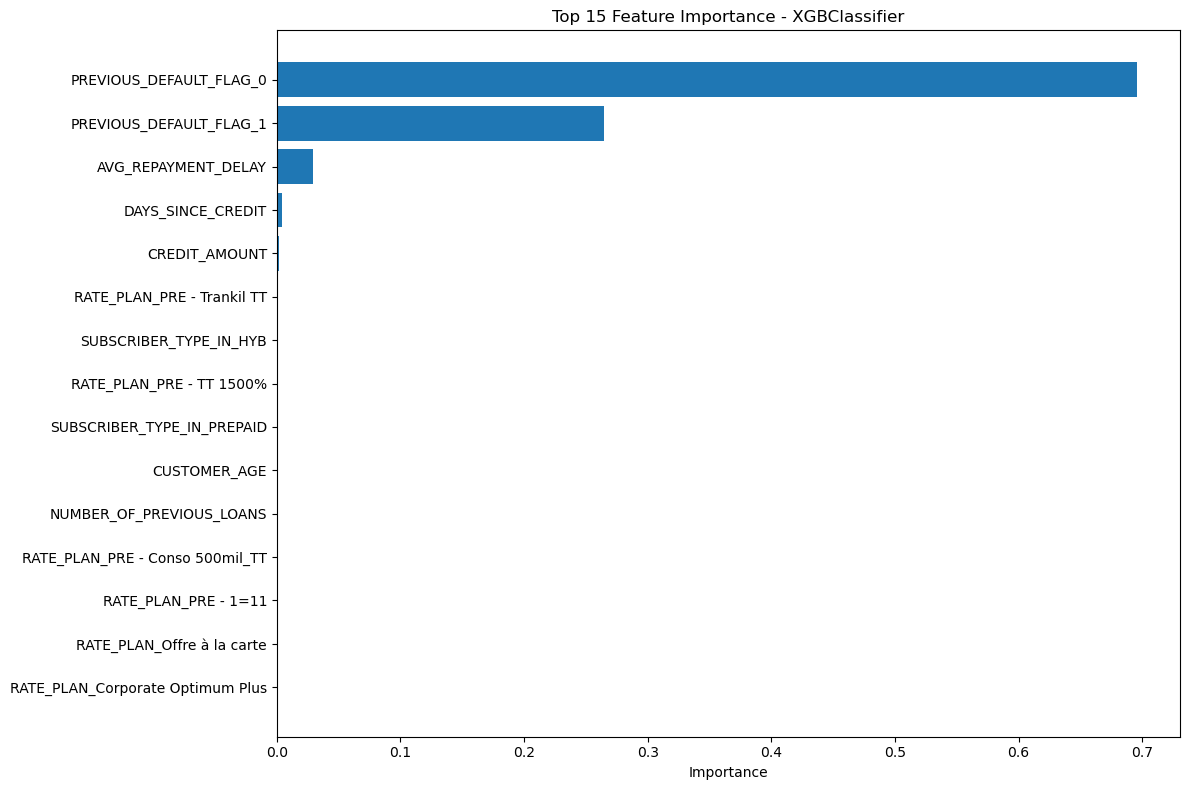

In [24]:
# Plot feature importance
plt.figure(figsize=(12, 8))
top_features = feature_importance_df.head(15)
plt.barh(range(len(top_features)), top_features['Importance'].values)
plt.yticks(range(len(top_features)), top_features['Feature'].values)
plt.xlabel('Importance')
plt.title('Top 15 Feature Importance - XGBClassifier')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

<Figure size 800x600 with 0 Axes>

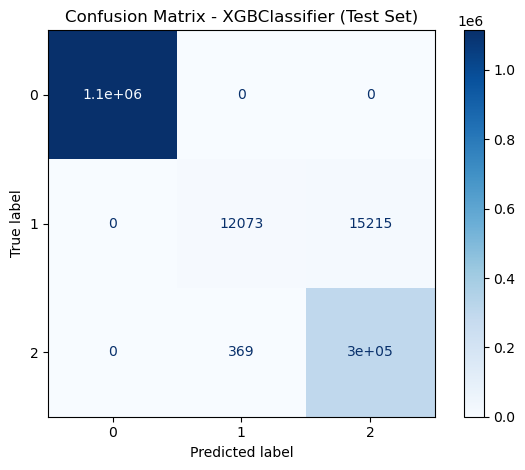

In [25]:
# Plot confusion matrix
from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(8, 6))
cm = confusion_matrix(y_test, y_test_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - XGBClassifier (Test Set)')
plt.tight_layout()
plt.show()

In [26]:
# Model summary comparison
summary_df = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Training Set': [train_accuracy, train_precision, train_recall, train_f1],
    'Test Set': [test_accuracy, test_precision, test_recall, test_f1]
})

print("=" * 60)
print("MODEL PERFORMANCE SUMMARY")
print("=" * 60)
print(summary_df.to_string(index=False))
print("\nNote: Training and test metrics should be similar.")
print("Large differences may indicate overfitting or underfitting.")

MODEL PERFORMANCE SUMMARY
   Metric  Training Set  Test Set
 Accuracy      0.989196  0.989171
Precision      0.989408  0.989368
   Recall      0.989196  0.989171
 F1-Score      0.987308  0.987280

Note: Training and test metrics should be similar.
Large differences may indicate overfitting or underfitting.


In [27]:
# ROC Curve (for binary classification)
from sklearn.metrics import roc_curve, auc

# Check if binary classification
unique_classes = np.unique(y)
if len(unique_classes) == 2:
    fpr, tpr, thresholds = roc_curve(y_test, y_test_pred_proba[:, 1])
    roc_auc = auc(fpr, tpr)
    
    plt.figure(figsize=(8, 6))
    plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
    plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve - XGBClassifier (Test Set)')
    plt.legend(loc="lower right")
    plt.tight_layout()
    plt.show()
    print(f"ROC AUC Score: {roc_auc:.4f}")
else:
    print(f"ROC Curve is for binary classification. This is a {len(unique_classes)}-class problem.")

ROC Curve is for binary classification. This is a 3-class problem.


In [30]:
# Save the model
import joblib

# Save model
model_path = 'xgb_reimburse_status_model.pkl'
joblib.dump(xgb_model, model_path)
print(f"Model saved to {model_path}")

# Save preprocessor
preprocessor_path = 'preprocessor.pkl'
joblib.dump(preprocessor, preprocessor_path)
print(f"Preprocessor saved to {preprocessor_path}")

# Save feature names
feature_names_path = 'feature_names.pkl'
joblib.dump(feature_names_after_transform, feature_names_path)
print(f"Feature names saved to {feature_names_path}")

print("\nAll model artifacts saved successfully!")

Model saved to xgb_reimburse_status_model.pkl
Preprocessor saved to preprocessor.pkl
Feature names saved to feature_names.pkl

All model artifacts saved successfully!


In [33]:
# Final Summary and Recommendations
print("=" * 80)
print("XGBCLASSIFIER MODEL - FINAL SUMMARY")
print("=" * 80)
print(f"\n✓ Model Type: XGBClassifier")
print(f"✓ Target Variable: REIMBURSE_STATUS")
print(f"✓ Features Used: {len(features)}")

print(f"\n✓ Test Set Accuracy: {test_accuracy:.4f}")
print(f"✓ Test Set F1-Score (Weighted): {test_f1:.4f}")
print(f"✓ Test Set Precision: {test_precision:.4f}")
print(f"✓ Test Set Recall: {test_recall:.4f}")

print(f"\n{'RECOMMENDATIONS:':}")
if abs(train_accuracy - test_accuracy) > 0.1:
    print(f"  - Note: Large gap between training ({train_accuracy:.4f}) and test accuracy ({test_accuracy:.4f})")
    print(f"    Consider: regularization, more data, or feature engineering")
else:
    print(f"  - Training and test accuracy are well-aligned (good generalization)")

print(f"\n✓ Model artifacts saved:")
print(f"  - Model: xgb_reimburse_status_model.pkl")
print(f"  - Preprocessor: preprocessor.pkl")
print(f"  - Feature Names: feature_names.pkl")

XGBCLASSIFIER MODEL - FINAL SUMMARY

✓ Model Type: XGBClassifier
✓ Target Variable: REIMBURSE_STATUS
✓ Features Used: 8

✓ Test Set Accuracy: 0.9892
✓ Test Set F1-Score (Weighted): 0.9873
✓ Test Set Precision: 0.9894
✓ Test Set Recall: 0.9892

RECOMMENDATIONS:
  - Training and test accuracy are well-aligned (good generalization)

✓ Model artifacts saved:
  - Model: xgb_reimburse_status_model.pkl
  - Preprocessor: preprocessor.pkl
  - Feature Names: feature_names.pkl
